In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
# Load news data
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Quick look
print("Shape:", news_df.shape)
print("\nFirst 5 rows:")
news_df.head()

Shape: (1407328, 6)

First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [18]:
# Data types and missing values
print("=== Data Types ===")
print(news_df.dtypes)
print("\n=== Missing Values ===")
print(news_df.isnull().sum())

# Convert date column to datetime
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')

print("\n=== Date Range ===")
print(f"From: {news_df['date'].min()}")
print(f"To: {news_df['date'].max()}")

=== Data Types ===
Unnamed: 0    int64
headline        str
url             str
publisher       str
date            str
stock           str
dtype: object

=== Missing Values ===
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

=== Date Range ===
From: 2011-04-27 21:01:48-04:00
To: 2020-06-11 17:12:35-04:00


=== Headline Length Statistics ===
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


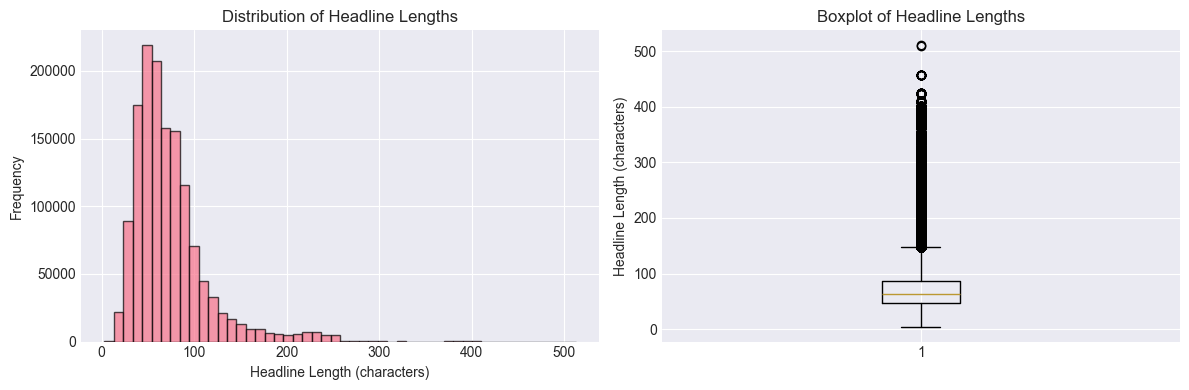

In [19]:
# Calculate headline lengths
news_df['headline_length'] = news_df['headline'].str.len()

# Statistics
print("=== Headline Length Statistics ===")
print(news_df['headline_length'].describe())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(news_df['headline_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Headline Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Headline Lengths')

# Boxplot
axes[1].boxplot(news_df['headline_length'])
axes[1].set_ylabel('Headline Length (characters)')
axes[1].set_title('Boxplot of Headline Lengths')

plt.tight_layout()
plt.show()

Total unique publishers: 1034

=== Top 10 Publishers ===
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


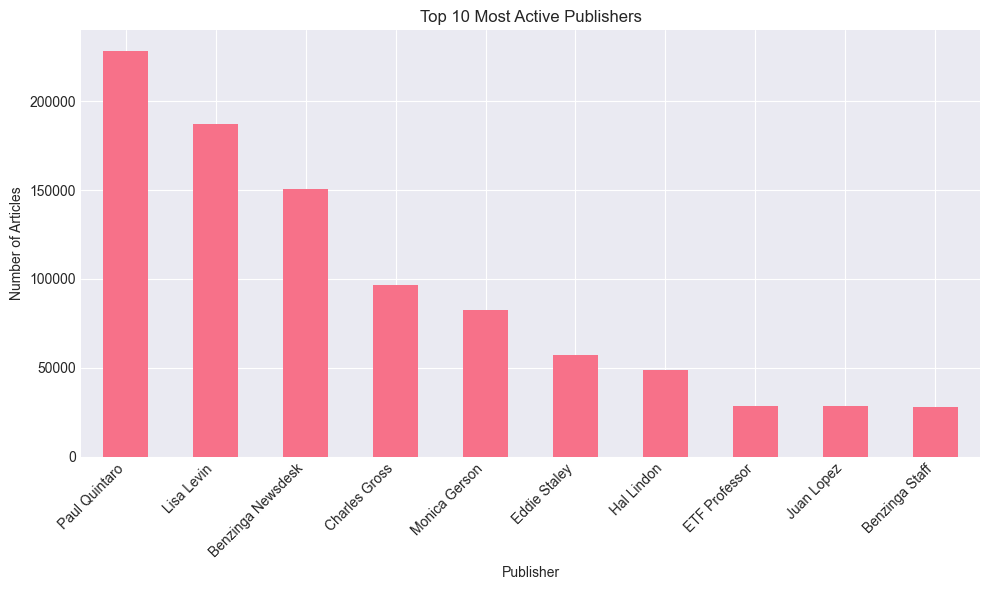

In [20]:
# Count articles per publisher
publisher_counts = news_df['publisher'].value_counts()

print(f"Total unique publishers: {len(publisher_counts)}")
print("\n=== Top 10 Publishers ===")
print(publisher_counts.head(10))

# Plot top 10
plt.figure(figsize=(10, 6))
publisher_counts.head(10).plot(kind='bar')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.title('Top 10 Most Active Publishers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

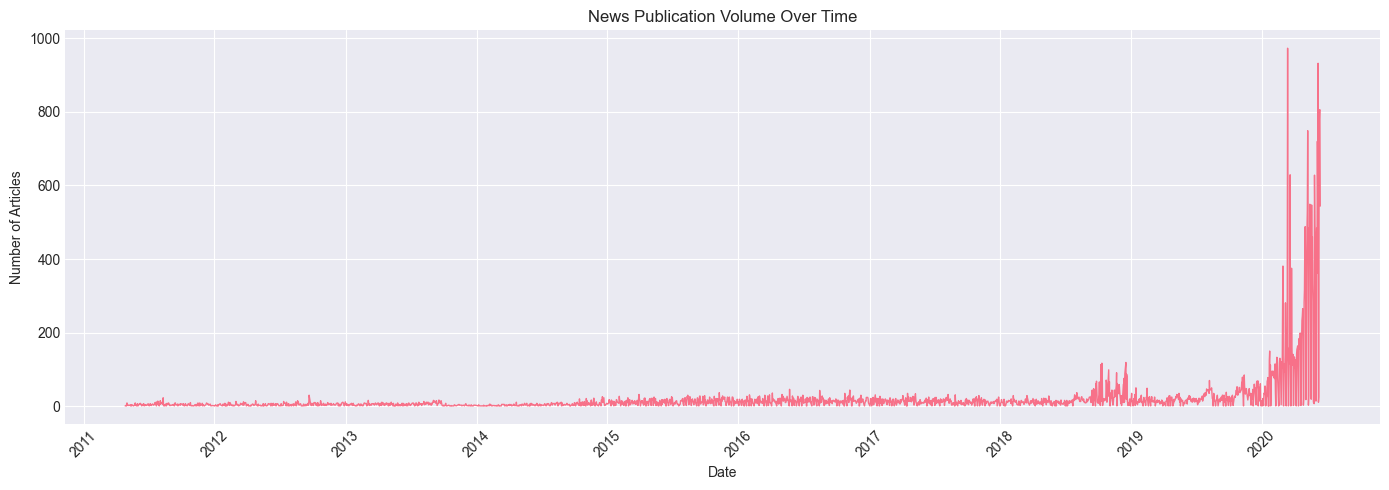


=== Top 5 Days with Highest News Volume ===
publish_date
2020-03-12    973
2020-06-05    932
2020-06-10    806
2020-06-09    804
2020-06-08    765
dtype: int64


In [21]:
# Extract date only (without time)
news_df['publish_date'] = news_df['date'].dt.date

# Count articles per day
daily_counts = news_df.groupby('publish_date').size()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(daily_counts.index, daily_counts.values, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.title('News Publication Volume Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top days
print("\n=== Top 5 Days with Highest News Volume ===")
print(daily_counts.nlargest(5))

=== Top 20 Most Common Words in Headlines ===
          word   count
18          vs  162099
15      stocks  161776
6          est  140604
5          eps  128897
7       market  120558
14      shares  114313
12     reports  108710
17      update   91723
4     earnings   87399
13       sales   79645
1     benzinga   74516
10          pt   73068
19        week   69572
0    announces   66591
9        price   64407
2          buy   64371
8          mid   62263
3   downgrades   61959
16     trading   61182
11      raises   57802


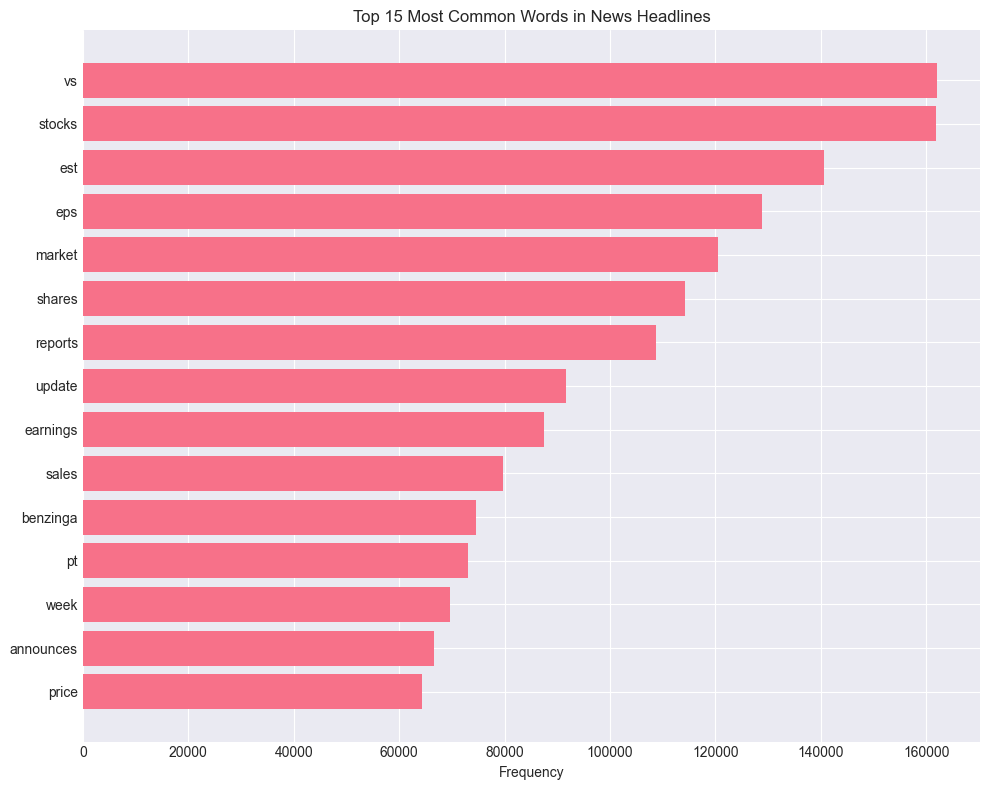

In [22]:
# Create word frequency
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(news_df['headline'].fillna('').astype(str))

# Get words and counts
words = vectorizer.get_feature_names_out()
word_counts = X.toarray().sum(axis=0)

# Create DataFrame
word_freq = pd.DataFrame({'word': words, 'count': word_counts})
word_freq = word_freq.sort_values('count', ascending=False)

print("=== Top 20 Most Common Words in Headlines ===")
print(word_freq)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(word_freq['word'][:15], word_freq['count'][:15])
plt.xlabel('Frequency')
plt.title('Top 15 Most Common Words in News Headlines')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

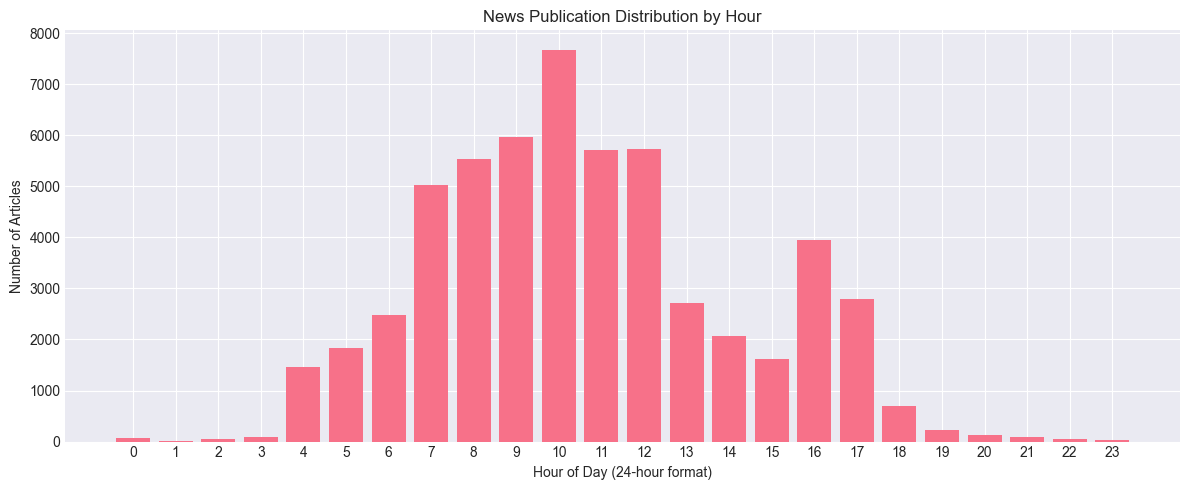


=== Peak Publishing Hours ===
hour
10.0    7669
9.0     5965
12.0    5732
11.0    5701
8.0     5527
Name: count, dtype: int64


In [23]:
# Extract hour
news_df['hour'] = news_df['date'].dt.hour

# Count by hour
hourly_counts = news_df['hour'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 5))
plt.bar(hourly_counts.index, hourly_counts.values)
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Articles')
plt.title('News Publication Distribution by Hour')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

print("\n=== Peak Publishing Hours ===")
print(hourly_counts.nlargest(5))